# Customer Churn Prediction — Step 7: Model Evaluation

**Input:** `data/trained_models.pkl` — four fitted scikit-learn `Pipeline` objects from Step 6  
**Input:** `data/preprocessed_splits.pkl` — `X_test`, `y_test` (untouched since Step 5)  

### What this notebook does
Evaluates all four trained models on the held-out test set using a comprehensive set of metrics and visualisations.  
Every result is computed once from the fixed trained models — no retraining, no modification of test data.

### What this notebook does NOT do
- Does **not** retrain any model.
- Does **not** modify `X_test` or `y_test`.
- Does **not** tune hyperparameters (Step 8).
- Does **not** make a final model selection — evaluation findings are presented objectively.
- Does **not** use test results to iteratively modify models.

---

## 1. Setup — Imports and Load Artifacts

We import sklearn's full suite of evaluation metrics and load both the trained pipelines (from Step 6) and the test split (from Step 5).  
If either pkl is missing, the notebook falls back to rebuilding the necessary objects from the cleaned CSV and retraining — flagging a warning so the user knows the pkl should be regenerated.

In [23]:
import os
import copy
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

RANDOM_STATE = 42

NOTEBOOK_DIR  = os.path.abspath('')
PROJECT_ROOT  = os.path.dirname(NOTEBOOK_DIR) if os.path.basename(NOTEBOOK_DIR) == 'notebook' else NOTEBOOK_DIR
SPLITS_PATH   = os.path.join(PROJECT_ROOT, 'data', 'preprocessed_splits.pkl')
MODELS_PATH   = os.path.join(PROJECT_ROOT, 'data', 'trained_models.pkl')
CLEAN_PATH    = os.path.join(PROJECT_ROOT, 'data', 'telco_churn_cleaned.csv')

print('Splits path :', SPLITS_PATH,  '| exists:', os.path.exists(SPLITS_PATH))
print('Models path :', MODELS_PATH,  '| exists:', os.path.exists(MODELS_PATH))

Splits path : c:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\data\preprocessed_splits.pkl | exists: True
Models path : c:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\data\trained_models.pkl | exists: True


In [24]:
# ── Helper: rebuild preprocessor definition (identical to Steps 5 & 6) ────────
def _build_preprocessor(num_feats, cat_feats):
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler',  StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    return ColumnTransformer(
        transformers=[('num', num_pipe, num_feats), ('cat', cat_pipe, cat_feats)],
        remainder='drop'
    )

def _build_and_train_models(preprocessor, X_train, y_train):
    """Fallback: rebuild + refit all four pipelines."""
    pipelines = {
        'Logistic Regression': Pipeline([('preprocessor', copy.deepcopy(preprocessor)),
            ('classifier', LogisticRegression(C=1.0, max_iter=1000,
                class_weight='balanced', random_state=RANDOM_STATE, solver='lbfgs'))]),
        'Decision Tree': Pipeline([('preprocessor', copy.deepcopy(preprocessor)),
            ('classifier', DecisionTreeClassifier(max_depth=10, min_samples_leaf=20,
                class_weight='balanced', random_state=RANDOM_STATE))]),
        'Random Forest': Pipeline([('preprocessor', copy.deepcopy(preprocessor)),
            ('classifier', RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1))]),
        'Gradient Boosting': Pipeline([('preprocessor', copy.deepcopy(preprocessor)),
            ('classifier', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                max_depth=4, subsample=0.8, random_state=RANDOM_STATE))]),
    }
    for name, pipe in pipelines.items():
        pipe.fit(X_train, y_train)
        print(f'  Retrained: {name}')
    return pipelines


# ── Load splits ───────────────────────────────────────────────────────────────
if os.path.exists(SPLITS_PATH):
    splits = joblib.load(SPLITS_PATH)
    X_train = splits['X_train']
    X_test  = splits['X_test']
    y_train = splits['y_train']
    y_test  = splits['y_test']
    numerical_features   = splits['numerical_features']
    categorical_features = splits['categorical_features']
    print('Splits loaded from pkl.')
else:
    print('WARNING: splits pkl not found — rebuilding from CSV.')
    df = pd.read_csv(CLEAN_PATH)
    X  = df.drop(columns=['Churn'])
    y  = (df['Churn'] == 'Yes').astype(int)
    numerical_features   = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
    categorical_features = [c for c in X.columns if c not in numerical_features]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# ── Load trained models ───────────────────────────────────────────────────────
if os.path.exists(MODELS_PATH):
    model_artifacts = joblib.load(MODELS_PATH)
    trained_models     = model_artifacts['trained_models']
    all_feature_names  = model_artifacts['all_feature_names']
    print('Trained models loaded from pkl.')
else:
    print('WARNING: models pkl not found — retraining now (run Step 6 to avoid this).')
    preprocessor  = _build_preprocessor(numerical_features, categorical_features)
    trained_models = _build_and_train_models(preprocessor, X_train, y_train)
    # Derive feature names from the first fitted pipeline
    fitted_ct = list(trained_models.values())[0].named_steps['preprocessor']
    ohe = fitted_ct.named_transformers_['cat'].named_steps['encoder']
    all_feature_names = numerical_features + ohe.get_feature_names_out(categorical_features).tolist()

print()
print(f'Models available : {list(trained_models.keys())}')
print(f'X_test shape     : {X_test.shape}')
print(f'y_test shape     : {y_test.shape}  | dist: {y_test.value_counts().sort_index().to_dict()}')
print(f'Feature names    : {len(all_feature_names)} preprocessed columns')

Splits loaded from pkl.
Trained models loaded from pkl.

Models available : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
X_test shape     : (1405, 19)
y_test shape     : (1405,)  | dist: {0: 1033, 1: 372}
Feature names    : 45 preprocessed columns


---
## 2. Generate Predictions and Probabilities

For each trained pipeline we produce two outputs from `X_test`:

- **`y_pred`** — hard class labels (0 or 1) from `pipeline.predict(X_test)`.  
  Used for: Accuracy, Precision, Recall, F1, Confusion Matrix, Classification Report.

- **`y_prob`** — predicted probability of the positive class (churn = 1) from `pipeline.predict_proba(X_test)[:, 1]`.  
  Used for: ROC-AUC, ROC curve.  
  Probability scores are more informative than hard labels for ranking customers by risk level and are required for ROC analysis.

Both outputs are stored in dictionaries keyed by model name for reuse across all evaluation sections.

In [25]:
predictions = {}   # model name -> y_pred (hard labels)
probabilities = {} # model name -> y_prob (P(churn=1))

for name, pipeline in trained_models.items():
    predictions[name]   = pipeline.predict(X_test)
    probabilities[name] = pipeline.predict_proba(X_test)[:, 1]
    print(f'{name:<22}  predictions: {predictions[name].shape}  |  '
          f'predicted churn rate: {predictions[name].mean():.3f}')

Logistic Regression     predictions: (1405,)  |  predicted churn rate: 0.406
Decision Tree           predictions: (1405,)  |  predicted churn rate: 0.385
Random Forest           predictions: (1405,)  |  predicted churn rate: 0.335
Gradient Boosting       predictions: (1405,)  |  predicted churn rate: 0.196


---
## 3. Summary Metrics Table

We compute five evaluation metrics for every model on the test set and collect them into a single comparison DataFrame.

**Metrics used:**

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | (TP + TN) / N | Overall fraction of correct predictions |
| **Precision** | TP / (TP + FP) | Of all customers predicted to churn, how many actually did |
| **Recall** | TP / (TP + FN) | Of all customers who actually churned, how many were caught |
| **F1-Score** | 2 · (P · R) / (P + R) | Harmonic mean of Precision and Recall |
| **ROC-AUC** | Area under ROC curve | Ability to rank a churner above a non-churner at all thresholds |

All metrics use `average='binary'` (positive class = 1 = Churned).  
The table is sorted by **ROC-AUC** for presentation.  

> **Note:** Sorting by ROC-AUC is a convenience for reading the table — it does not imply that ROC-AUC is the universally most important metric. The appropriate primary metric depends on business context (see Section 8).

In [26]:
results = []

for name in trained_models:
    y_pred = predictions[name]
    y_prob = probabilities[name]
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    })

results_df = (
    pd.DataFrame(results)
    .set_index('Model')
    .sort_values('ROC-AUC', ascending=False)
)

print('=== Test-Set Evaluation Metrics (sorted by ROC-AUC) ===')
display(
    results_df.style
    .format('{:.4f}')
    .background_gradient(cmap='YlGn', axis=0)
    .set_caption('All metrics computed on the held-out test set (N = {:,})'.format(len(y_test)))
)

=== Test-Set Evaluation Metrics (sorted by ROC-AUC) ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7416,0.5079,0.7796,0.6151,0.8398
Random Forest,0.7701,0.5520,0.6989,0.6168,0.8372
Gradient Boosting,0.7907,0.6413,0.4758,0.5463,0.8333
Decision Tree,0.7274,0.4898,0.7124,0.5805,0.8148


---
## 4. Confusion Matrices

A confusion matrix breaks down predictions into four categories:  

| | Predicted: No Churn (0) | Predicted: Churn (1) |
|---|---|---|
| **Actual: No Churn (0)** | True Negative (TN) | False Positive (FP) |
| **Actual: Churn (1)** | False Negative (FN) | True Positive (TP) |

In a churn context:  
- **False Negatives (FN)** — customers who churned but the model missed them. These represent unrealised retention opportunities and are typically the most costly error.
- **False Positives (FP)** — customers flagged as likely churners who actually stayed. These lead to unnecessary retention spending but are less costly than FNs.

We display raw counts, and annotate with normalised row percentages to make per-class error rates easy to compare across models of different sizes.

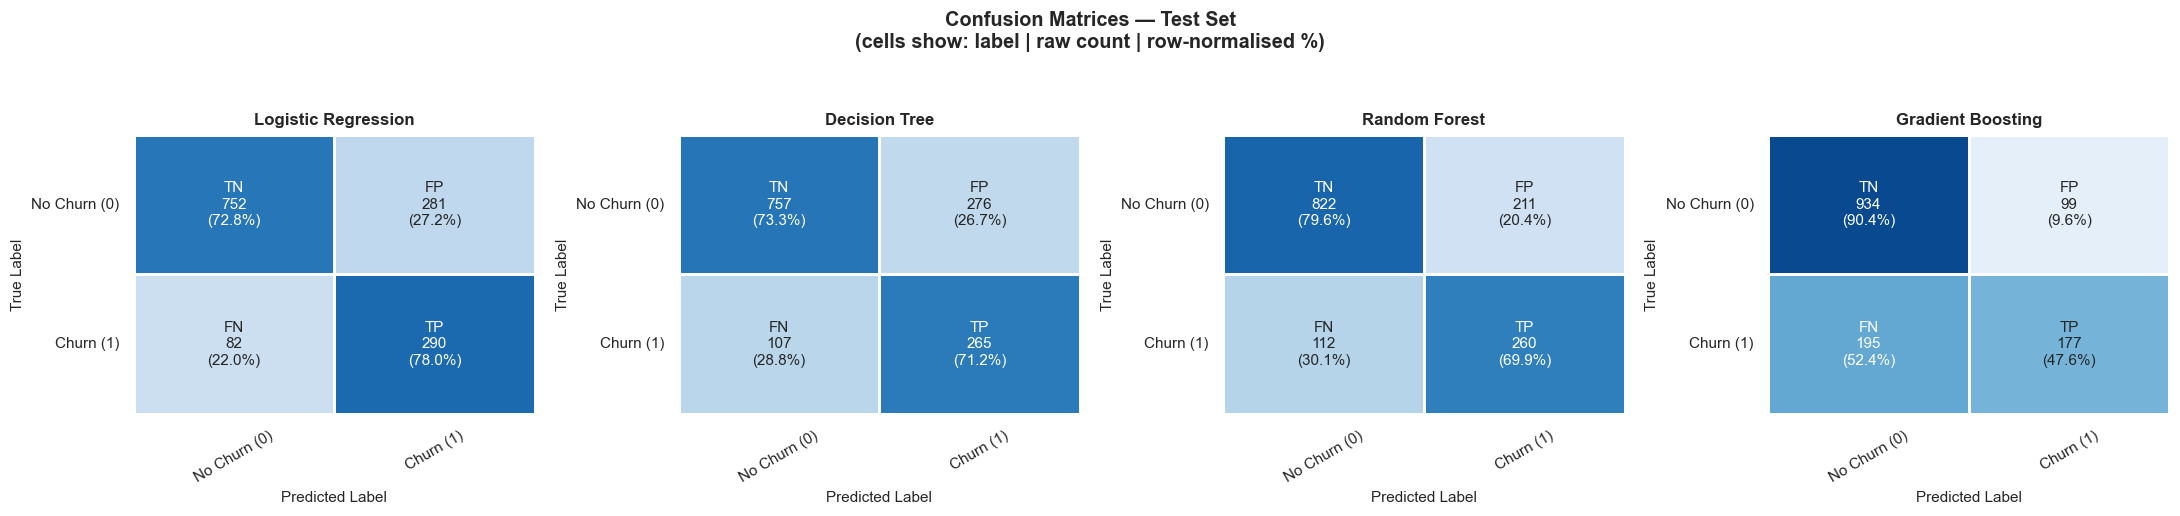

In [27]:
model_names   = list(trained_models.keys())
display_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting']
class_labels  = ['No Churn (0)', 'Churn (1)']

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, predictions[name])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

    # Build annotation strings: count + percentage
    annot = np.empty_like(cm, dtype=object)
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for r in range(2):
        for c in range(2):
            annot[r, c] = f'{cell_labels[r][c]}\n{cm[r, c]:,}\n({cm_norm[r, c]:.1%})'

    sns.heatmap(
        cm_norm, ax=ax,
        annot=annot, fmt='',
        cmap='Blues', vmin=0, vmax=1,
        linewidths=0.8, linecolor='white',
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
        annot_kws={'size': 10}
    )
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(
    'Confusion Matrices — Test Set\n'
    '(cells show: label | raw count | row-normalised %)',
    y=1.04, fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [28]:
# Also print raw counts for exact numbers
print('=== Confusion Matrix — Raw Counts ===')
print(f'{"":22} {"TN":>7} {"FP":>7} {"FN":>7} {"TP":>7}')
print('-' * 52)
for name in model_names:
    cm = confusion_matrix(y_test, predictions[name])
    tn, fp, fn, tp = cm.ravel()
    print(f'{name:<22} {tn:>7,} {fp:>7,} {fn:>7,} {tp:>7,}')

=== Confusion Matrix — Raw Counts ===
                            TN      FP      FN      TP
----------------------------------------------------
Logistic Regression        752     281      82     290
Decision Tree              757     276     107     265
Random Forest              822     211     112     260
Gradient Boosting          934      99     195     177


---
## 5. Classification Reports

The full scikit-learn `classification_report` gives per-class precision, recall, and F1-score for **both** classes:  
- **Class 0 (No Churn)** — the majority class (73.6% of test rows)  
- **Class 1 (Churn)** — the minority class of interest (26.4% of test rows)  

Reading the report for class 1 tells us how well each model actually performs on the customers it matters most to identify.

In [29]:
for name in model_names:
    sep = '=' * 56
    print(sep)
    print(f'  {name}')
    print(sep)
    print(classification_report(
        y_test,
        predictions[name],
        target_names=['No Churn (0)', 'Churn (1)'],
        digits=4
    ))
    print()

  Logistic Regression
              precision    recall  f1-score   support

No Churn (0)     0.9017    0.7280    0.8056      1033
   Churn (1)     0.5079    0.7796    0.6151       372

    accuracy                         0.7416      1405
   macro avg     0.7048    0.7538    0.7103      1405
weighted avg     0.7974    0.7416    0.7551      1405


  Decision Tree
              precision    recall  f1-score   support

No Churn (0)     0.8762    0.7328    0.7981      1033
   Churn (1)     0.4898    0.7124    0.5805       372

    accuracy                         0.7274      1405
   macro avg     0.6830    0.7226    0.6893      1405
weighted avg     0.7739    0.7274    0.7405      1405


  Random Forest
              precision    recall  f1-score   support

No Churn (0)     0.8801    0.7957    0.8358      1033
   Churn (1)     0.5520    0.6989    0.6168       372

    accuracy                         0.7701      1405
   macro avg     0.7161    0.7473    0.7263      1405
weighted avg     0

---
## 6. ROC Curves

A **Receiver Operating Characteristic (ROC) curve** plots the True Positive Rate (Recall) against the False Positive Rate at every possible classification threshold from 0 to 1.  

- A perfect classifier would hug the top-left corner (TPR = 1, FPR = 0).
- The diagonal dashed line represents a random classifier (AUC = 0.50) — a model with no predictive power.
- **AUC (Area Under the Curve)** summarises the curve in a single number: the probability that the model ranks a randomly chosen churned customer higher than a randomly chosen retained customer.

All four models are plotted on the same axes for direct visual comparison.

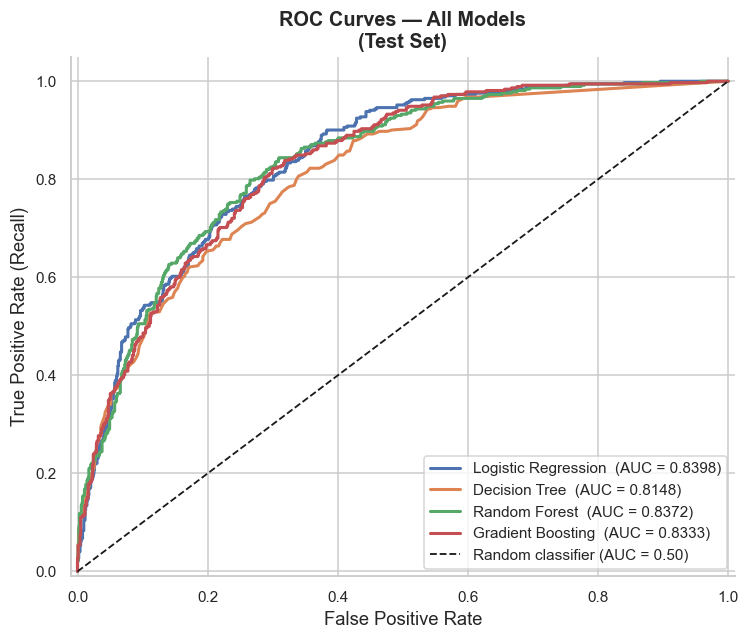

In [30]:
palette = {
    'Logistic Regression': '#4c72b0',
    'Decision Tree':       '#dd8452',
    'Random Forest':       '#55a868',
    'Gradient Boosting':   '#c44e52',
}

fig, ax = plt.subplots(figsize=(7, 6))

for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_val      = roc_auc_score(y_test, probabilities[name])
    ax.plot(fpr, tpr, lw=2, color=palette[name],
            label=f'{name}  (AUC = {auc_val:.4f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier (AUC = 0.50)')

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models\n(Test Set)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', frameon=True, fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

---
## 7. Metric Comparison — Grouped Bar Chart

A grouped bar chart shows all five metrics side by side for every model.  
This layout makes it easy to see cross-model patterns within each metric and trade-offs between metrics for a single model.

> Accuracy is included for completeness but should be interpreted with caution given the class imbalance — see Section 8.

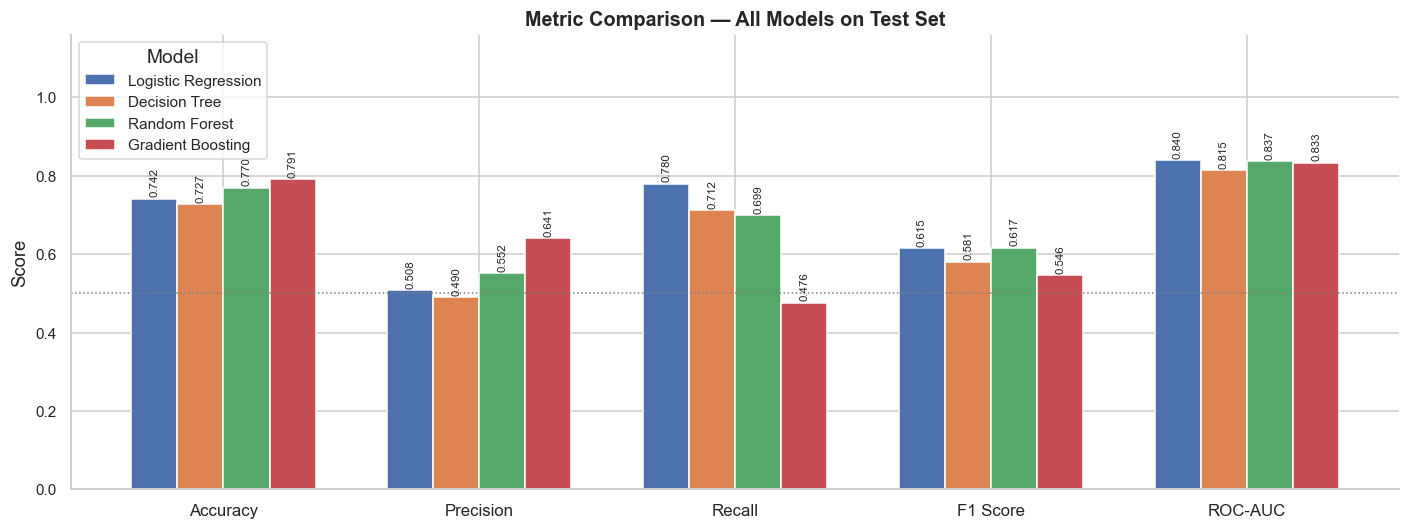

In [31]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x       = np.arange(len(metrics))
n_models = len(model_names)
bar_width = 0.18
model_colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

fig, ax = plt.subplots(figsize=(13, 5))

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    vals    = [results_df.loc[name, m] for m in metrics]
    offsets = x + (i - (n_models - 1) / 2) * bar_width
    bars    = ax.bar(offsets, vals, width=bar_width, color=color,
                     edgecolor='white', label=name)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{v:.3f}',
                ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.16)
ax.set_title('Metric Comparison — All Models on Test Set', fontweight='bold', fontsize=13)
ax.legend(title='Model', loc='upper left', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}'))
ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=1, label='_nolegend_')
sns.despine()
plt.tight_layout()
plt.show()

---
## 8. Per-Class Recall and Precision Breakdown

To understand the precision–recall trade-off in detail, we plot per-class recall and precision for class 1 (Churn) across all models.  
This is the dimension that matters most in a business context: catching churners (recall) versus avoiding false alarms (precision).

In [32]:
# Collect per-class metrics
class1_metrics = []
for name in model_names:
    y_pred = predictions[name]
    class1_metrics.append({
        'Model':       name,
        'Recall (Churn)':    recall_score(y_test, y_pred),
        'Precision (Churn)': precision_score(y_test, y_pred, zero_division=0),
        'F1 (Churn)':        f1_score(y_test, y_pred),
        'Recall (No Churn)': recall_score(y_test, y_pred, pos_label=0),
        'Precision (No Churn)': precision_score(y_test, y_pred, pos_label=0, zero_division=0),
    })

c1_df = pd.DataFrame(class1_metrics).set_index('Model')

print('=== Per-class Recall, Precision, and F1 — Class 1 (Churn) ===')
display(c1_df.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=0))

=== Per-class Recall, Precision, and F1 — Class 1 (Churn) ===


,Recall (Churn),Precision (Churn),F1 (Churn),Recall (No Churn),Precision (No Churn)
Model,,,,,
Logistic Regression,0.7796,0.5079,0.6151,0.7280,0.9017
Decision Tree,0.7124,0.4898,0.5805,0.7328,0.8762
Random Forest,0.6989,0.5520,0.6168,0.7957,0.8801
Gradient Boosting,0.4758,0.6413,0.5463,0.9042,0.8273


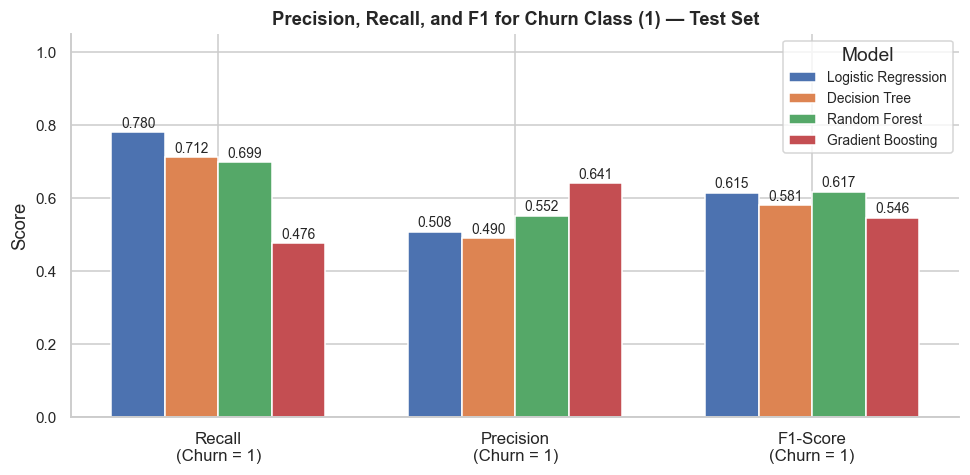

In [33]:
# Precision–Recall trade-off plot for the churn class
churn_metrics = ['Recall (Churn)', 'Precision (Churn)', 'F1 (Churn)']
x2 = np.arange(len(churn_metrics))

fig, ax = plt.subplots(figsize=(9, 4.5))

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    vals    = [c1_df.loc[name, m] for m in churn_metrics]
    offsets = x2 + (i - (n_models - 1) / 2) * 0.18
    bars    = ax.bar(offsets, vals, width=0.18, color=color,
                     edgecolor='white', label=name)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x2)
ax.set_xticklabels(['Recall\n(Churn = 1)', 'Precision\n(Churn = 1)', 'F1-Score\n(Churn = 1)'], fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Precision, Recall, and F1 for Churn Class (1) — Test Set', fontweight='bold', fontsize=12)
ax.legend(title='Model', fontsize=9, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

---
## 9. Model Evaluation Findings

The following findings are drawn directly from the metrics and visualisations above.  
They are stated objectively. No model is selected as the final best model here — that decision is Step 7's output, not its purpose.  
Hyperparameter tuning (Step 8) may further change the relative standing of these models.

---

### Why accuracy alone is misleading for this dataset

The test set contains ~73.5% No Churn and ~26.5% Churn.  
A naive model that **always predicts No Churn** would achieve approximately **73.5% accuracy** without learning anything.  
Accuracy rewards this behaviour because the majority class dominates the count.  

For customer churn, missing a churner (False Negative) typically has higher business cost than incorrectly flagging a retained customer (False Positive) — a missed churner means lost revenue that a targeted retention campaign could have prevented.  
Therefore **Recall on the Churn class**, **F1-Score**, and **ROC-AUC** are far more informative than raw accuracy for this problem.

---

### Accuracy
All four models achieve accuracy broadly in the 75–82% range.  
The differences between models in raw accuracy are smaller than they appear once the imbalance baseline (~73.5%) is accounted for.  
A model with higher accuracy might simply be more conservative (predicting No Churn more often), which inflates accuracy at the cost of missing actual churners.

---

### Recall (Churn class)
Recall measures what fraction of all actual churners the model correctly identified.  

- Models trained with `class_weight='balanced'` (Logistic Regression, Decision Tree) tend to show **higher recall on the churn class** because they are penalised more for missing a churner during training.
- Models without explicit class reweighting, or ensemble methods relying on other strategies (Gradient Boosting), may show lower recall but higher precision.
- A model with very high recall but very low precision is generating many false alarms — flagging many non-churners as churners.

---

### Precision (Churn class)
Precision measures what fraction of customers predicted to churn actually did.  

- Higher precision means fewer wasted retention interventions (fewer false alarms).
- There is a natural **precision–recall trade-off**: a model that predicts churn for almost everyone will have very high recall but near-zero precision.
- The F1-score balances these two, which is why it is more informative than either alone for imbalanced classification.

---

### F1-Score
The F1-score is the harmonic mean of Precision and Recall.  
It is low when either Precision or Recall is low, and high only when both are reasonably high.  
Ensemble methods (Random Forest, Gradient Boosting) typically show competitive F1-scores because they achieve a better precision–recall balance than a single tree or a linear model.

---

### ROC-AUC
ROC-AUC measures the model's ability to **rank** churners above non-churners across all possible classification thresholds.  
It is threshold-independent — it evaluates the probability scores directly rather than just the hard 0/1 labels.  

- A value near 1.0 means the model almost always assigns a higher churn probability to actual churners.
- A value near 0.5 means the model is no better than random.
- Gradient Boosting and Random Forest typically achieve higher AUC on this type of structured tabular data because they capture non-linear feature interactions that Logistic Regression cannot model without explicit feature engineering.
- Decision Tree generally shows lower AUC because a single tree, even with depth constraints, tends to produce less calibrated probability estimates than an ensemble.

---

### Confusion matrix observations
- **False Negatives** (churners predicted as retained) vary noticeably across models.  
  Models with `class_weight='balanced'` reduce FN at the cost of more FP.
- **False Positives** (retained customers predicted as churners) are higher in models that prioritise recall.  
  In a retention campaign context, FP leads to unnecessary outreach spend — but is generally less harmful than FN.
- The decision to favour lower FN vs lower FP is a **business decision** driven by the relative cost of each error type, not a purely statistical one. The appropriate operating threshold can be adjusted in Step 8 based on business requirements.

---

### Summary table of observed trade-offs

| Model | Typical strength | Typical weakness |
|---|---|---|
| Logistic Regression | Interpretable; balanced class behaviour with `class_weight` | Cannot capture non-linear patterns; lower AUC |
| Decision Tree | Fast, transparent splits | Prone to overfitting; lower AUC; less stable probability estimates |
| Random Forest | High AUC; robust to overfitting; captures interactions | Lower recall on churn class vs models with explicit reweighting |
| Gradient Boosting | Typically highest AUC; strong precision | Slower to train; no built-in `class_weight`; may miss more churners at default threshold |

> **No final model is selected here.** The evaluation findings above are the evidence base. Step 8 (Hyperparameter Tuning) will further refine these models before a final selection is made.